<a href="https://colab.research.google.com/github/juttigasairaj-coder/Edge-detection-CV-4/blob/main/cv4_edge_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

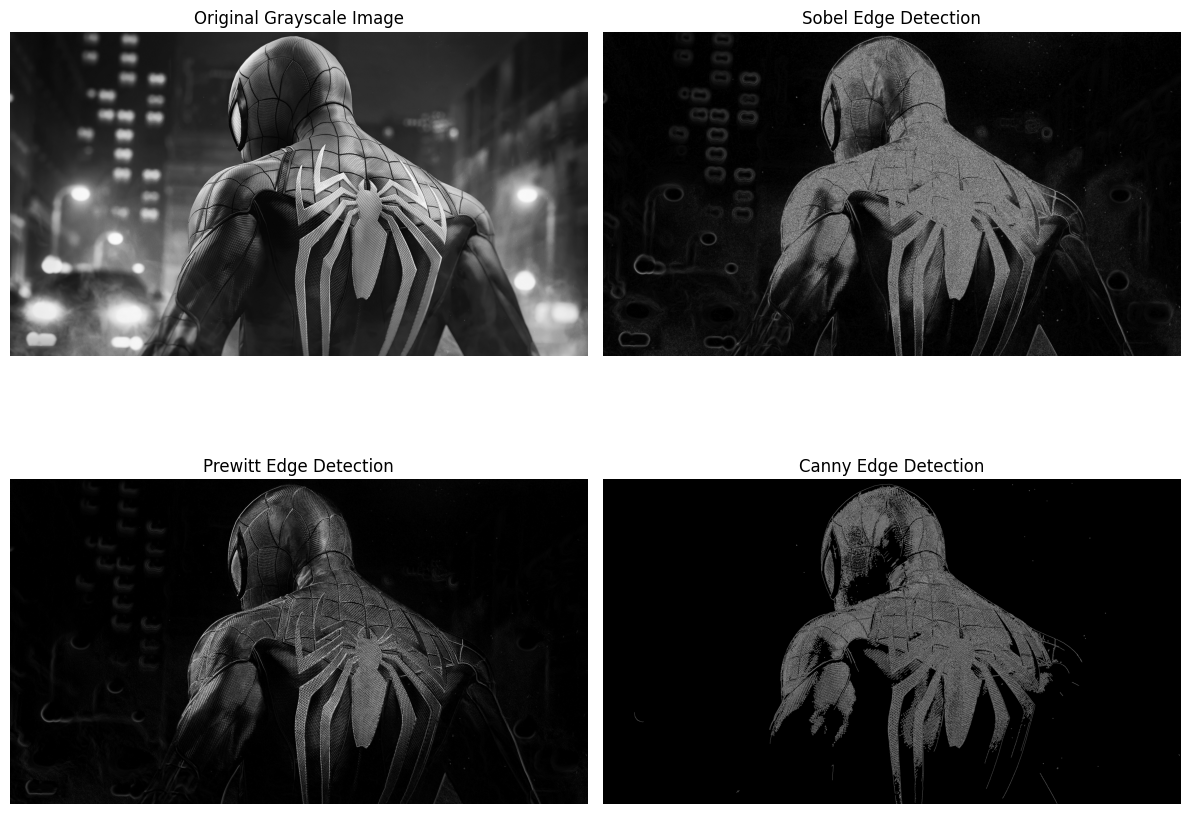

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to display images
def show_comparison(original, sobel, prewitt, canny):
    plt.figure(figsize=(12, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    # Sobel Edge Detection
    plt.subplot(2, 2, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title('Sobel Edge Detection')
    plt.axis('off')

    # Prewitt Edge Detection
    plt.subplot(2, 2, 3)
    plt.imshow(prewitt, cmap='gray')
    plt.title('Prewitt Edge Detection')
    plt.axis('off')

    # Canny Edge Detection
    plt.subplot(2, 2, 4)
    plt.imshow(canny, cmap='gray')
    plt.title('Canny Edge Detection')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# 1. Read an image
img = cv2.imread('/content/spiderman.jpg', 0)

if img is None:
    print('Error loading image')
else:

    # Sobel Operator
    # Gradient in X and Y direction
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Combine gradient
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)

    # Prewitt Operator
    # Define kernels
    kernelsx = np.array([[1, 1, 1],[0, 0, 0],[-1, -1, -1]])
    kernelsy = np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]])

    # Apply kernels using filter2D
    prewittx = cv2.filter2D(img, -1, kernelsx)
    prewitty = cv2.filter2D(img, -1, kernelsy)

    # Convert to float for magnitude
    prewittx = np.float32(prewittx)
    prewitty = np.float32(prewitty)

    # Combine gradient
    prewitt_combined = cv2.magnitude(prewittx, prewitty)

    # Canny Edge Detection
    canny_edges = cv2.Canny(img, 100, 200)

    # Display images
    show_comparison(img, np.uint8(np.absolute(sobel_combined)), np.uint8(np.absolute(prewitt_combined)), canny_edges)